<a href="https://colab.research.google.com/github/girishbetter/Machine-Learning-Models-for-Mobile-Price-Classification-/blob/main/05_SVM_for_mobile_price_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from google.colab import drive

In [26]:
drive.mount("/content/drive")
path = "/content/drive/MyDrive/ML_DATASET/mobile_price_classification.csv"
data = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# Display the first 5 rows of the dataset to understand its structure
display(data.head())

# Get a concise summary of the DataFrame, including data types and non-null values
print(data.info())

# Check for missing values in each column
print('\nMissing values per column:')
print(data.isnull().sum())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

Based on the `data.info()` output, all columns are non-null. However, it's good practice to ensure all numerical columns are indeed numerical and handle categorical features appropriately if they exist before scaling or modeling.

Let's check the descriptive statistics for numerical columns and then visualize the distributions.

In [28]:
# Display descriptive statistics for numerical columns
display(data.describe())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [29]:
X = data.drop("price_range", axis=1)
y = data["price_range"]

In [30]:
test_sizes = [0.2, 0.3]
for ts in test_sizes:
    train_pct = int((1 - ts) * 100)
    test_pct = int(ts * 100)

    print(f"\n--- SVM: Evaluating Split {train_pct}:{test_pct} ---")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=42)

    # Scale the features to increase accuracy!
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train the model on the SCALED data
    model = SVC(kernel='linear', random_state=42) # 'linear' kernel often works very well for mobile price data
    model.fit(X_train_scaled, y_train)

    # Predict and calculate accuracy
    pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, pred)

    print(f"Accuracy: {accuracy:.4f}")


--- SVM: Evaluating Split 80:20 ---
Accuracy: 0.9700

--- SVM: Evaluating Split 70:30 ---
Accuracy: 0.9533


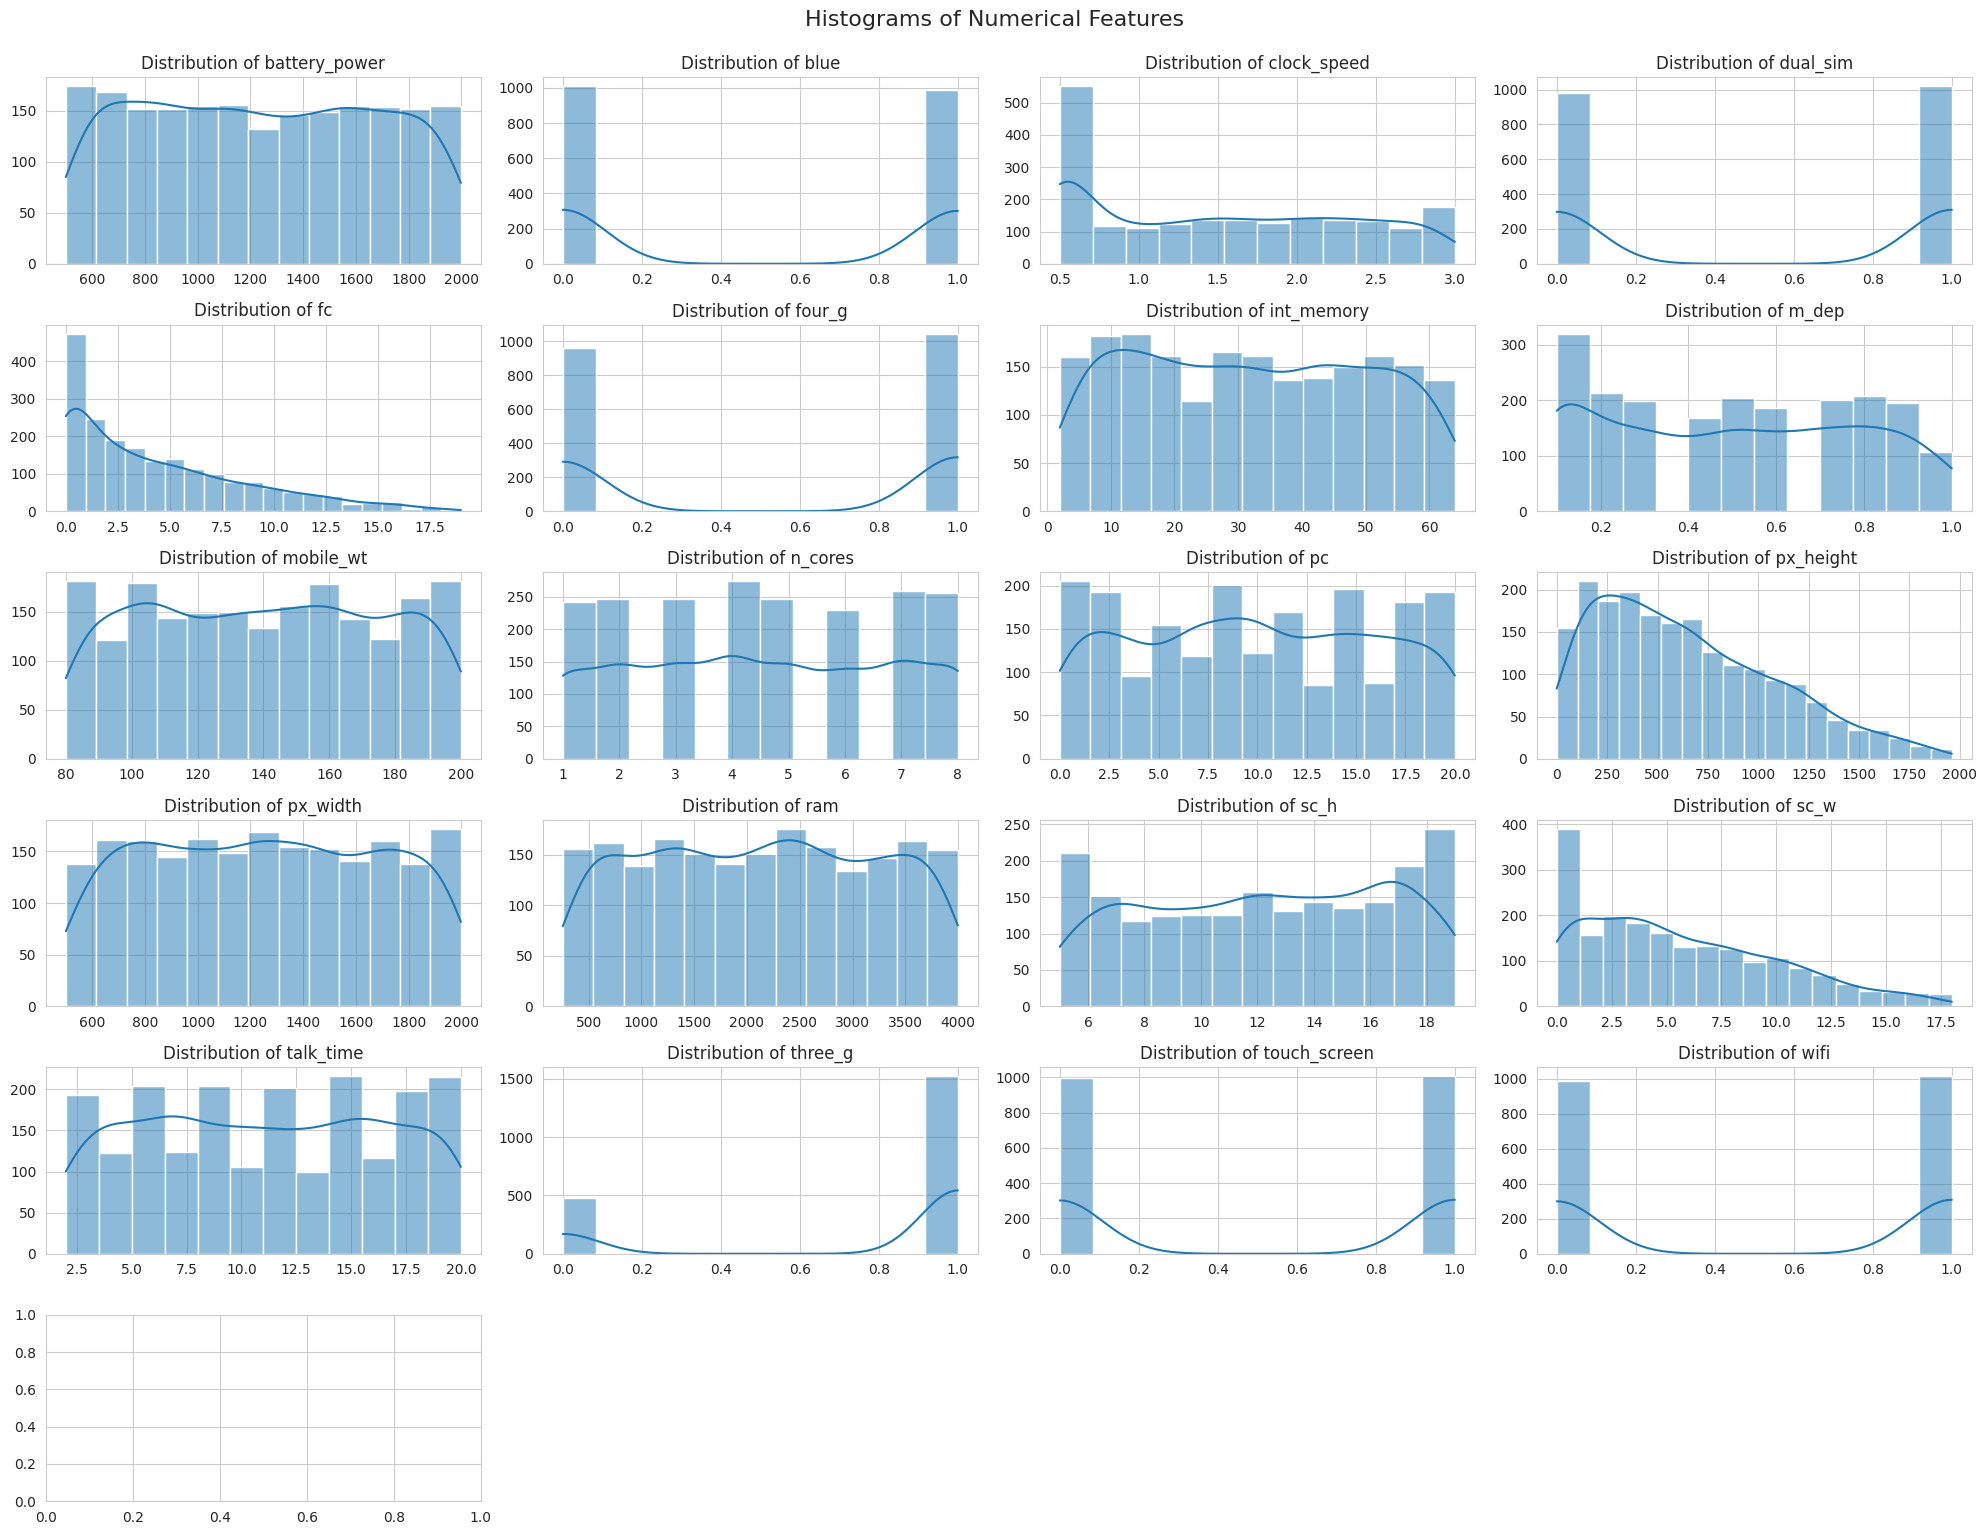

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# Distribution of numerical features
fig, axes = plt.subplots(ncols=4, nrows=(len(data.select_dtypes(include=['number']).columns) // 4) + 1, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(data.select_dtypes(include=['number']).columns):
    if col != 'price_range': # Exclude the target variable from numerical distribution plots for now
        sns.histplot(data[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.show()

### Exploratory Data Analysis (EDA) - Visualizations

Let's visualize the distribution of key features and the target variable, as well as the correlations between numerical features.

/tmp/ipykernel_1232/663424571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_range', data=data, palette='viridis')


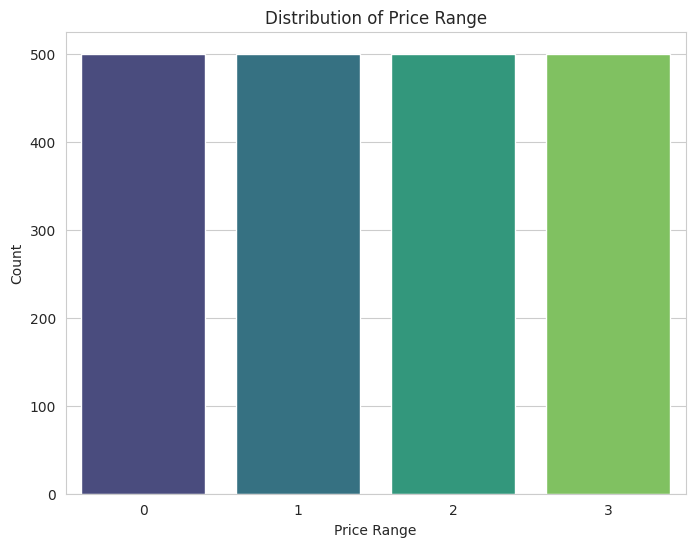

In [32]:
# Distribution of the target variable 'price_range'
plt.figure(figsize=(8, 6))
sns.countplot(x='price_range', data=data, palette='viridis')
plt.title('Distribution of Price Range')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()

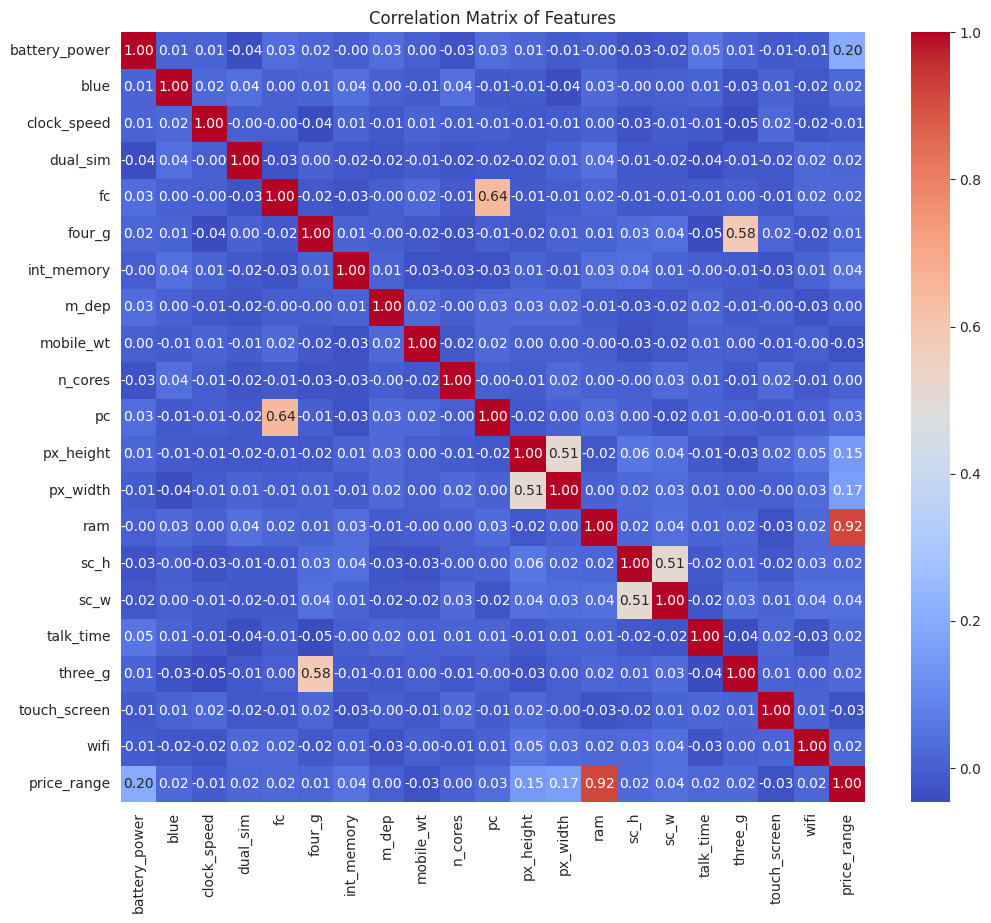

In [33]:
# Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()